# Imports

In [1]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from src.data import load_data

sns.set(style="whitegrid")


# Load data

In [2]:
df = load_data("../data/raw/reviews.csv")
df.head()


2026-02-23 16:13:19,282 | INFO | src.data | Loaded dataset with shape=(18442, 9)
2026-02-23 16:13:19,296 | INFO | src.data | No missing values detected in dataset.
2026-02-23 16:13:19,302 | INFO | src.data | Target 'Recommended IND' mean (recommend rate)=0.8162
2026-02-23 16:13:19,302 | INFO | src.data | Target 'Recommended IND' counts={1: 15053, 0: 3389}


,Clothing ID,Age,Title,Review Text,Positive Feedback Count,Division Name,Department Name,Class Name,Recommended IND
0,1077,60,Some major design flaws,I had such high hopes for this dress and reall...,0,General,Dresses,Dresses,0
1,1049,50,My favorite buy!,"I love, love, love this jumpsuit. it's fun, fl...",0,General Petite,Bottoms,Pants,1
2,847,47,Flattering shirt,This shirt is very flattering to all due to th...,6,General,Tops,Blouses,1
3,1080,49,Not for the very petite,"I love tracy reese dresses, but this one is no...",4,General,Dresses,Dresses,0
4,858,39,Cagrcoal shimmer fun,I aded this in my basket at hte last mintue to...,1,General Petite,Tops,Knits,1


# Dataset structure

In [3]:
df.shape


(18442, 9)

In [4]:
df.info()


<class 'pandas.DataFrame'>
RangeIndex: 18442 entries, 0 to 18441
Data columns (total 9 columns):
 #   Column                   Non-Null Count  Dtype
---  ------                   --------------  -----
 0   Clothing ID              18442 non-null  int64
 1   Age                      18442 non-null  int64
 2   Title                    18442 non-null  str  
 3   Review Text              18442 non-null  str  
 4   Positive Feedback Count  18442 non-null  int64
 5   Division Name            18442 non-null  str  
 6   Department Name          18442 non-null  str  
 7   Class Name               18442 non-null  str  
 8   Recommended IND          18442 non-null  int64
dtypes: int64(4), str(5)
memory usage: 1.3 MB


# Missing values

In [5]:
df.isna().sum().sort_values(ascending=False)


Clothing ID                0
Age                        0
Title                      0
Review Text                0
Positive Feedback Count    0
Division Name              0
Department Name            0
Class Name                 0
Recommended IND            0
dtype: int64

### *Dataset overview*

The dataset contains 18,442 customer reviews with nine structured attributes, including demographic, product category, engagement metrics, and textual feedback.

No missing values were detected, simplifying preprocessing and eliminating the need for imputation at this stage.

This dataset combines structured and unstructured data, making it suitable for a multimodal machine learning pipeline.

# Target distribution

In [6]:
df["Recommended IND"].value_counts(normalize=True)


Recommended IND
1    0.816235
0    0.183765
Name: proportion, dtype: float64

2026-02-23 16:13:19,725 | INFO | matplotlib.category | Using categorical units to plot a list of strings that are all parsable as floats or dates. If these strings should be plotted as numbers, cast to the appropriate data type before plotting.
2026-02-23 16:13:19,747 | INFO | matplotlib.category | Using categorical units to plot a list of strings that are all parsable as floats or dates. If these strings should be plotted as numbers, cast to the appropriate data type before plotting.


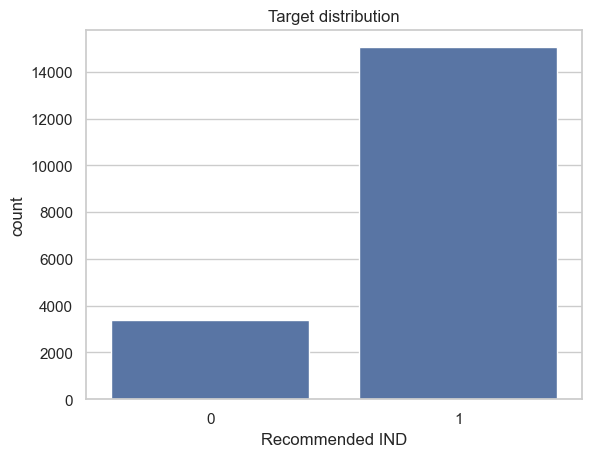

In [7]:
sns.countplot(x="Recommended IND", data=df)
plt.title("Target distribution")
plt.show()


### *Target distribution and class imbalance overview*

The target variable shows a strong class imbalance, with approximately 81% of reviews labeled as recommended and 19% as not recommended.

This imbalance indicates that accuracy alone will not be a reliable evaluation metric, as a naive classifier predicting only the majority class would already achieve high performance.

Implications for modeling:

* Evaluation should prioritize Precision, Recall, and F1-score.

* Stratified sampling must be used during train/test splitting.

* Class-weighted models will likely improve performance.

* Threshold tuning may be required depending on the business objective.

This insight directly influences the modeling strategy and evaluation framework for the classification pipeline.

# Age vs. Recommendation

2026-02-23 16:13:20,242 | INFO | matplotlib.category | Using categorical units to plot a list of strings that are all parsable as floats or dates. If these strings should be plotted as numbers, cast to the appropriate data type before plotting.
2026-02-23 16:13:20,268 | INFO | matplotlib.category | Using categorical units to plot a list of strings that are all parsable as floats or dates. If these strings should be plotted as numbers, cast to the appropriate data type before plotting.


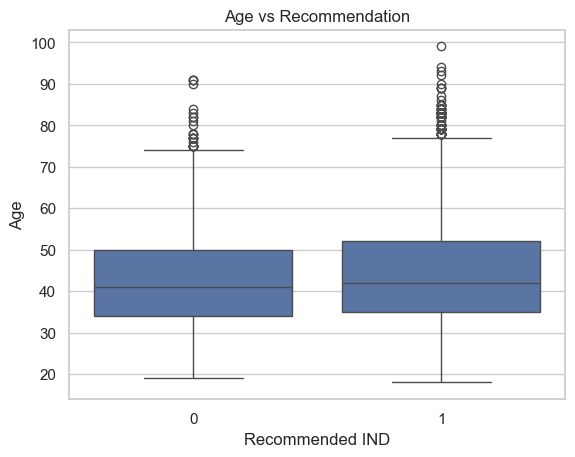

In [8]:
sns.boxplot(x="Recommended IND", y="Age", data=df)
plt.title("Age vs Recommendation")
plt.show()

### *Demographic signal (Age vs Recommendation) overview*

The age distributions for recommended and non-recommended reviews show substantial overlap.

Although the recommended group presents a slightly higher median age, the interquartile ranges and dispersion indicate that age alone is unlikely to be a strong discriminative feature.

Implications for modeling:

* Age should be retained as a numerical feature.

* However, it is expected to contribute marginal predictive power compared to textual features.

* Feature importance analysis after training will help confirm its actual contribution.

This suggests that demographic features may provide contextual signal but are unlikely to dominate model predictions.

# Categories vs Recommendation

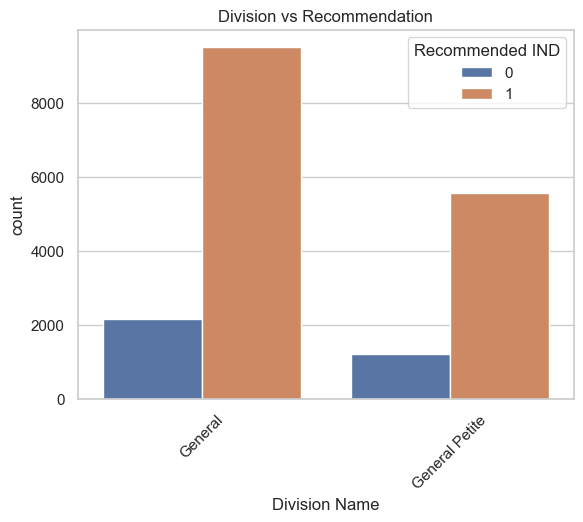

In [9]:
sns.countplot(x="Division Name", hue="Recommended IND", data=df)
plt.xticks(rotation=45)
plt.title("Division vs Recommendation")
plt.show()

### *Category influence (Division Name vs Recommendation) overview*

The recommendation rate appears to vary across product divisions, suggesting that product category may influence customer satisfaction patterns.

Both divisions show high recommendation rates, but the relative proportion of negative feedback differs.

Implications for modeling:

* Categorical features such as Division Name should be included in the pipeline.

* One-hot encoding is appropriate given the limited number of unique categories.

* Interaction between product category and textual sentiment may improve predictive performance.

This indicates that structured categorical features may complement textual signals in the final model.

# Text size

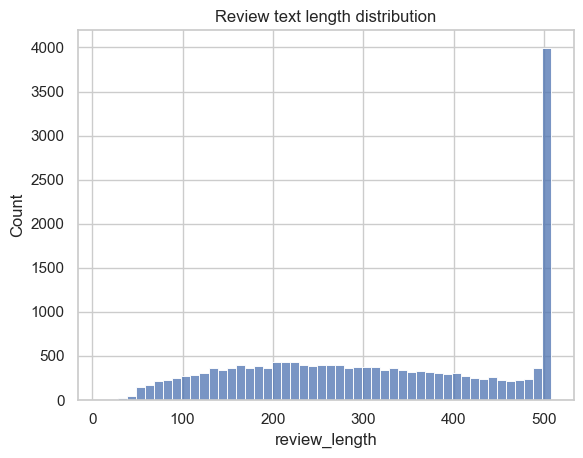

In [10]:
df["review_length"] = df["Review Text"].fillna("").apply(len)

sns.histplot(df["review_length"], bins=50)
plt.title("Review text length distribution")
plt.show()

### *Text signal strength overview*

The review length distribution shows significant variability, with many medium-length reviews and some substantially longer entries.

Longer reviews typically contain richer contextual and emotional information, which is likely to provide strong predictive signal for recommendation classification.

Implications for modeling:

* Text is expected to be the dominant predictive feature in this task.

* TF-IDF vectorization is an appropriate baseline representation.

* Lemmatization and stopword removal will help normalize textual inputs.

* Combining Title and Review Text may enhance semantic representation.

This analysis suggests that the problem is primarily a sentiment classification task augmented by structured contextual features.

# EDA Summary & Modeling Strategy

Based on the exploratory analysis:

* The dataset is clean and complete.

* The target variable is strongly imbalanced.

* Textual features are expected to dominate predictive performance.

* Structured features (age, category) provide contextual refinement.

* Logistic Regression with TF-IDF is a strong baseline choice.

* Stratified splitting and class-weighted training are required.

The next step is to implement a robust modeling pipeline that integrates preprocessing and classification in a reproducible and scalable way.